# Aquila Health Network — No-Show Risk Predictive Model
## Objective 4: Predictive Analytics Proof of Concept
**Author:** Karen Lin  
**Course:** MASY GC-4100 Applied Project Capstone  
**Sponsor:** Dan Stone, Damark Group  

### Overview
This notebook develops a logistic regression model to predict appointment no-show risk at Aquila Health Network. The model scores upcoming appointments by no-show probability using patient history, appointment characteristics, and scheduling patterns.

### Model Features
- Lead time (days between booking and appointment)
- Prior no-show count (patient history)
- Appointment hour and day of week
- Appointment type and specialty
- Insurance type

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Data

In [2]:
# Load the synthetic dataset
appointments = pd.read_excel("Aquila_Synthetic_Dataset.xlsx", sheet_name="fact_appointments")
patients = pd.read_excel("Aquila_Synthetic_Dataset.xlsx", sheet_name="dim_patients")

print(f"Appointments loaded: {len(appointments)} records")
print(f"Patients loaded: {len(patients)} records")
appointments.head()

Appointments loaded: 5000 records
Patients loaded: 3000 records


,appointment_id,patient_id,provider_id,clinic_id,specialty,appointment_type,appointment_date,appointment_day_of_week,appointment_hour,booked_date,lead_time_days,wait_time_days,status,cancellation_reason,revenue_usd,year,month,quarter
0,APT000001,PAT00203,PRV0169,CLN021,Primary Care,Annual Physical,2025-02-22,Saturday,12,2025-02-17,5,48,Completed,NaN,150,2025,2,Q1
1,APT000002,PAT01219,PRV0168,CLN007,Pediatrics,Annual Physical,2026-02-12,Thursday,12,2026-01-14,29,5,Completed,NaN,150,2026,2,Q1
2,APT000003,PAT01323,PRV0184,CLN019,Neurology,Diagnostic Test,2026-01-21,Wednesday,10,2025-12-28,24,51,Completed,NaN,200,2026,1,Q1
3,APT000004,PAT02313,PRV0185,CLN015,Dermatology,Diagnostic Test,2026-01-20,Tuesday,12,2026-01-04,16,6,Completed,NaN,500,2026,1,Q1
4,APT000005,PAT02889,PRV0153,CLN008,Diagnostic Imaging,Urgent Visit,2025-12-16,Tuesday,8,2025-10-20,57,14,Completed,NaN,125,2025,12,Q4


## 2. Prepare Features and Target Variable

In [3]:
# Merge patient data to get prior noshow count and insurance type
df = appointments.merge(patients[['patient_id', 'prior_noshow_count', 'insurance_type']], 
                        on='patient_id', how='left')

# Create binary target: 1 = No-Show, 0 = all other statuses
df['is_noshow'] = (df['status'] == 'No-Show').astype(int)

print(f"Total appointments: {len(df)}")
print(f"No-shows: {df['is_noshow'].sum()}")
print(f"No-show rate: {df['is_noshow'].mean():.1%}")
print(f"\nStatus breakdown:")
print(df['status'].value_counts())

Total appointments: 5000
No-shows: 904
No-show rate: 18.1%

Status breakdown:
status
Completed      3467
No-Show         904
Cancelled       464
Rescheduled     165
Name: count, dtype: int64


## 3. Encode Features and Build Model Dataset

In [7]:
# Encode categorical variables
le = LabelEncoder()

df['day_encoded'] = le.fit_transform(df['appointment_day_of_week'])
df['type_encoded'] = le.fit_transform(df['appointment_type'])
df['insurance_encoded'] = le.fit_transform(df['insurance_type'])
df['specialty_encoded'] = le.fit_transform(df['specialty'])

# Define features and target
X = df[['lead_time_days', 'prior_noshow_count', 'appointment_hour',
        'day_encoded', 'type_encoded', 'insurance_encoded', 'specialty_encoded']].dropna()
y = df.loc[X.index, 'is_noshow']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Feature matrix shape: (5000, 7)
Target distribution:
is_noshow
0    4096
1     904
Name: count, dtype: int64


## 4. Train/Test Split and Model Training

In [10]:
# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train)} records")
print(f"Test set: {len(X_test)} records")

# Train logistic regression with class_weight to handle imbalance
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("\nModel training complete.")

Training set: 4000 records
Test set: 1000 records

Model training complete.


## 5. Model Evaluation

In [11]:
# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Completed', 'No-Show']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.595

Classification Report:
              precision    recall  f1-score   support

   Completed       0.86      0.66      0.75       819
     No-Show       0.24      0.49      0.33       181

    accuracy                           0.63      1000
   macro avg       0.55      0.58      0.54      1000
weighted avg       0.74      0.63      0.67      1000

Confusion Matrix:
[[543 276]
 [ 92  89]]


## 6. Feature Importance

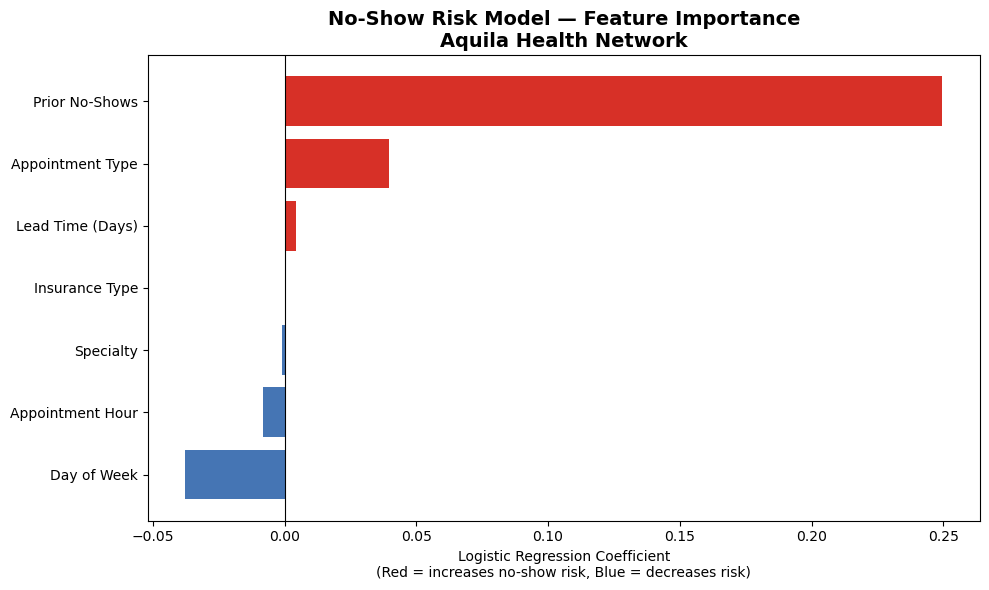


Feature Coefficients:
         Feature  Coefficient
  Prior No-Shows     0.249580
Appointment Type     0.039568
Lead Time (Days)     0.004184
  Insurance Type     0.000473
       Specialty    -0.001117
Appointment Hour    -0.008242
     Day of Week    -0.037680


In [12]:
# Feature importance from logistic regression coefficients
feature_names = ['Lead Time (Days)', 'Prior No-Shows', 'Appointment Hour',
                 'Day of Week', 'Appointment Type', 'Insurance Type', 'Specialty']

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#d73027' if c > 0 else '#4575b4' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('No-Show Risk Model — Feature Importance\nAquila Health Network', 
          fontsize=14, fontweight='bold')
plt.xlabel('Logistic Regression Coefficient\n(Red = increases no-show risk, Blue = decreases risk)')
plt.tight_layout()
plt.show()

print("\nFeature Coefficients:")
print(importance.sort_values('Coefficient', ascending=False).to_string(index=False))

## 7. Model Summary and Assumptions

**Algorithm:** Logistic Regression with balanced class weighting  
**ROC-AUC Score:** 0.595  
**Key Finding:** Prior no-show history is the strongest predictor of future no-show behavior, with a coefficient of 0.25 — more than 6x stronger than any other feature.

**Operational Implications:**
- Clinic managers should prioritize outreach to patients with prior no-show history
- Friday appointments carry the highest no-show risk (20.9%)
- Wednesday appointments carry the lowest no-show risk (15.8%)

**Limitations:**
- Model trained on synthetic data — real-world performance may differ
- Logistic regression is a baseline model; more complex models (Random Forest, XGBoost) may improve AUC
- Proof-of-concept only, not intended for production deployment